<a href="https://colab.research.google.com/github/s32230019/UAS-MACHINE-LEARNING/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A. PRE PROCESSING DATA


In [1]:
# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
## 2. Membaca dan Menampilkan Dataset
# MEMBACA DATASET CSV
df = pd.read_csv('Dry_Bean_Dataset.csv')

# MENAMPILKAN 5 DATA PERTAMA
print("5 Data Pertama:")
display(df.head())

# MENAMPILKAN JUMLAH BARIS DAN KOLOM
print("\nJumlah Data dan Kolom:")
print(df.shape)

5 Data Pertama:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



Jumlah Data dan Kolom:
(13611, 17)


In [3]:
## 3. Pengecekan Informasi & Missing Value
# MENAMPILKAN INFORMASI DATASET
print("Informasi Dataset:")
df.info()

# CEK APAKAH ADA DATA KOSONG
print("\nMissing Value:")
print(df.isnull().sum())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object

Jumlah Tiap Class:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


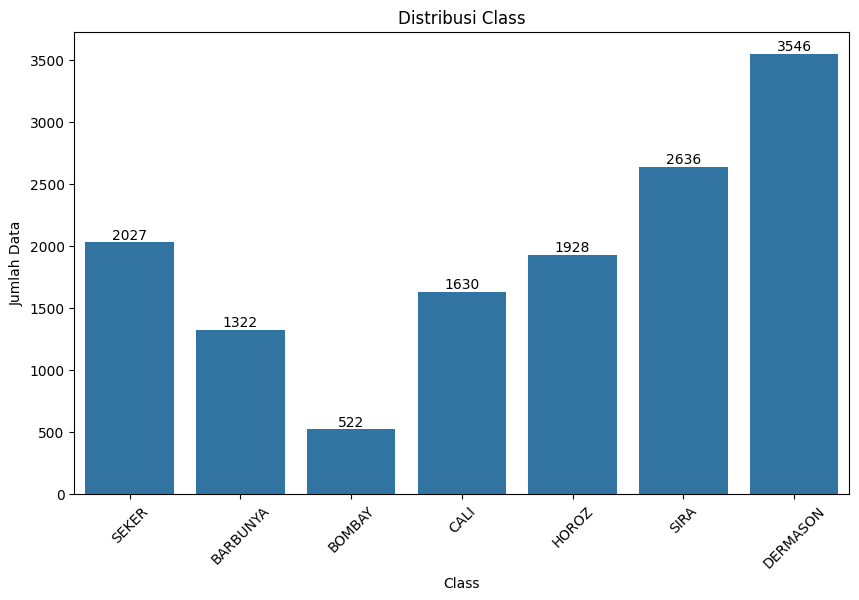

In [4]:
## 4. Analisis dan Visualisasi Distribusi Kelas
# MENAMPILKAN JUMLAH TIAP CLASS
print("Jumlah Tiap Class:")
print(df['Class'].value_counts())

# VISUALISASI JUMLAH TIAP CLASS
plt.figure(figsize=(10,6))
ax = sns.countplot(x='Class', data=df)

plt.title('Distribusi Class')
plt.xlabel('Class')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45)

# MENAMPILKAN ANGKA DI ATAS BAR
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.show()

Statistik Deskriptif:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


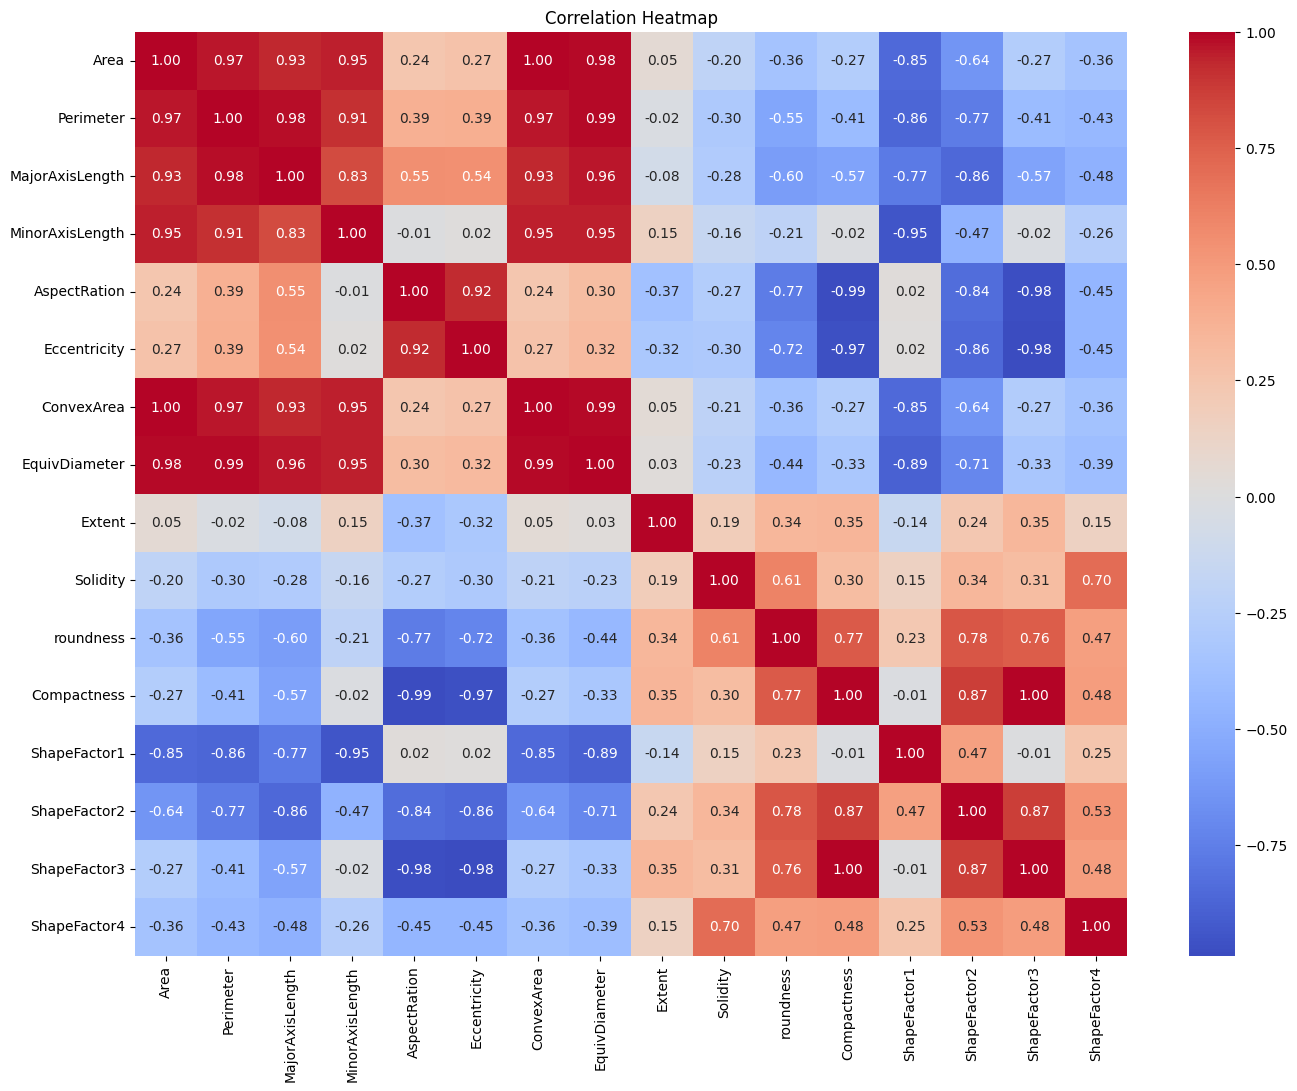

In [5]:
## 5. Statistik Deskriptif dan Korelasi Antar Fitur
# MENAMPILKAN STATISTIK DESKRIPTIF
print("Statistik Deskriptif:")
display(df.describe())

# VISUALISASI KORELARSI ANTAR FITUR
plt.figure(figsize=(16,12))
sns.heatmap(
    df.drop('Class', axis=1).corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [6]:
## 6. Label Encoding dan Standardisasi Fitur
# MENGUBAH LABEL CLASS MENJADI ANGKA
le = LabelEncoder()
df['Class_Label'] = le.fit_transform(df['Class'])

print("Encoding Class:")
display(df[['Class', 'Class_Label']].head())

# MEMISAHKAN FITUR DAN LABEL
X = df.drop(['Class', 'Class_Label'], axis=1)
y = df['Class_Label']

# STANDARDISASI DATA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData Setelah Standardisasi (5 baris pertama):")
print(X_scaled[:5])

Encoding Class:


,Class,Class_Label
0,SEKER,5
1,SEKER,5
2,SEKER,5
3,SEKER,5
4,SEKER,5



Data Setelah Standardisasi (5 baris pertama):
[[-0.84074853 -1.1433189  -1.30659814 -0.63115304 -1.56505251 -2.18572039
  -0.84145059 -1.0633406   0.28908744  0.36761343  1.42386707  1.8391164
   0.68078638  2.40217287  1.92572347  0.83837103]
 [-0.82918764 -1.01392388 -1.39591111 -0.43444458 -1.96978438 -3.68603953
  -0.82610154 -1.04421674  0.69747682 -0.46290658  0.23105404  2.49544929
   0.3679669   3.10089314  2.68970162  0.77113842]
 [-0.80715717 -1.07882906 -1.25235661 -0.58573461 -1.51429132 -2.04533608
  -0.80870371 -1.00808399  0.57819522  0.51841687  1.25286494  1.76484275
   0.60312889  2.23509147  1.84135576  0.91675514]
 [-0.78574055 -0.97721522 -1.27882531 -0.43929028 -1.74161826 -2.74221072
  -0.77397521 -0.97333689  0.67125962 -2.24176709  0.51504917  2.08171549
   0.40171781  2.51507474  2.20424996 -0.19798544]
 [-0.78123896 -1.09738406 -1.38047091 -0.26666336 -2.11799263 -4.53502829
  -0.78428628 -0.96607974  0.47602028  0.80477244  1.8749924   2.76533032
   0.11826

In [7]:
## 7. Menyimpan Hasil Preprocessing
# MENYIMPAN HASIL PREPROCESSING Ke CSV
df.to_csv('dry_bean_preprocessed.csv', index=False)

print("File berhasil disimpan:")
print("dry_bean_preprocessed.csv")

File berhasil disimpan:
dry_bean_preprocessed.csv


# B. UNSUPERVISED LEARNING


In [8]:
# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [9]:
## 2. Memuat Data & Inisialisasi Fitur
# MEMBACA DATASET HASIL PREPROCESSING
df = pd.read_csv('dry_bean_preprocessed.csv')

print(f"Jumlah Data dan Kolom: {df.shape}")

le = LabelEncoder()
df['Class_Label'] = le.fit_transform(df['Class'])

# MEMISAHKAN FITUR & SCALING
X = df.drop(['Class', 'Class_Label'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Jumlah Data dan Kolom: (13611, 18)


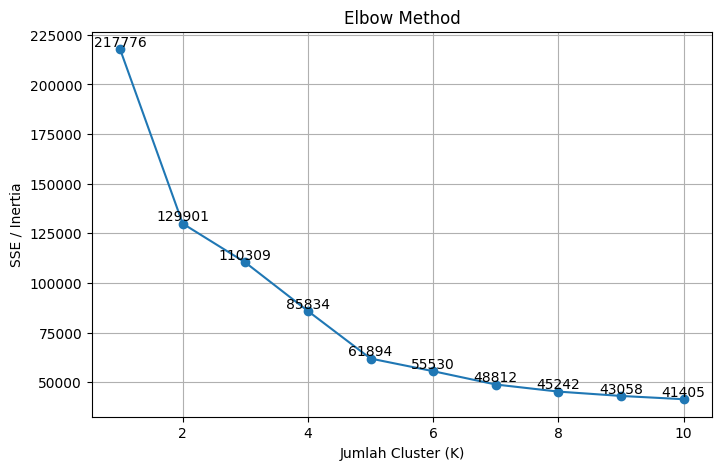

In [10]:
## 3. Penentuan K Terbaik (Elbow Method)
# ELBOW METHOD
sse = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# VISUALISASI ELBOW METHOD
plt.figure(figsize=(8,5))
plt.plot(K, sse, marker='o')

for i, value in enumerate(sse):
    plt.text(K[i], value, f'{value:.0f}', ha='center', va='bottom')

plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

Silhouette Score Evaluasi:
K = 2, Score = 0.3962
K = 3, Score = 0.2970
K = 4, Score = 0.3187
K = 5, Score = 0.3569
K = 6, Score = 0.2991
K = 7, Score = 0.3094
K = 8, Score = 0.3031
K = 9, Score = 0.2643
K = 10, Score = 0.2622


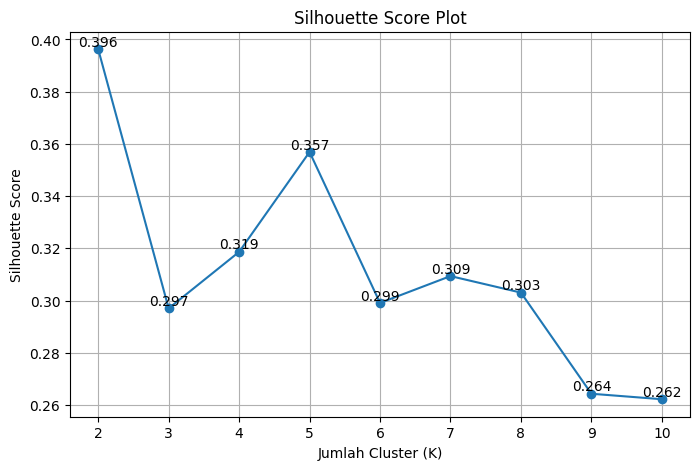

In [11]:
## 4. Evaluasi Kualitas Kluster (Silhouette Score)
# SILHOUETTE SCORE
print("Silhouette Score Evaluasi:")
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"K = {k}, Score = {score:.4f}")

# VISUALISASI SILHOUETTE SCORE
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')

for i, value in enumerate(silhouette_scores):
    plt.text(i + 2, value, f'{value:.3f}', ha='center', va='bottom')

plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Plot')
plt.grid(True)
plt.show()

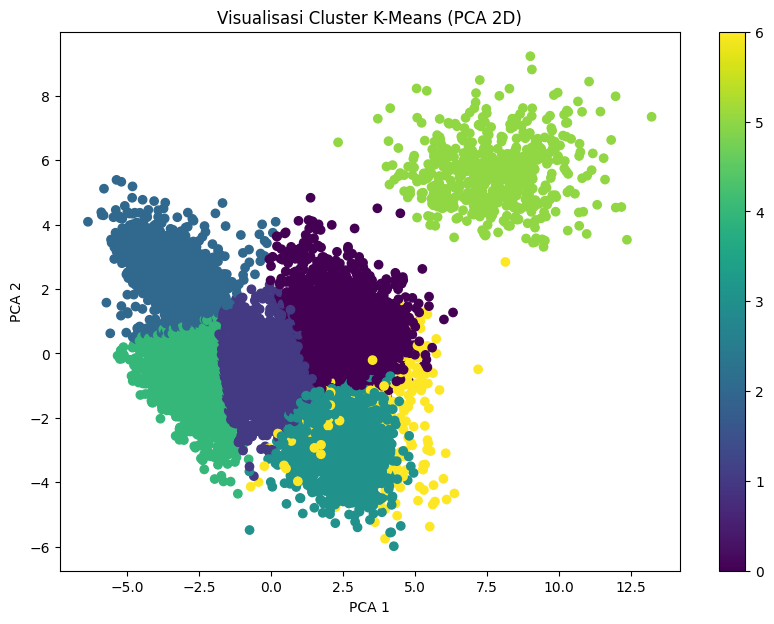

In [12]:
## 5. Pemodelan K-Means ($K=7$) & Visualisasi PCA
# MEMBUAT MODEL K-MEANS DENGAN 7 CLUSTER
kmeans = KMeans(n_clusters=7, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

# PCA UNTUK REDUKSI DIMENSI (2D VISUALISASI)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualisasi Cluster K-Means (PCA 2D)')
plt.colorbar(scatter)
plt.show()

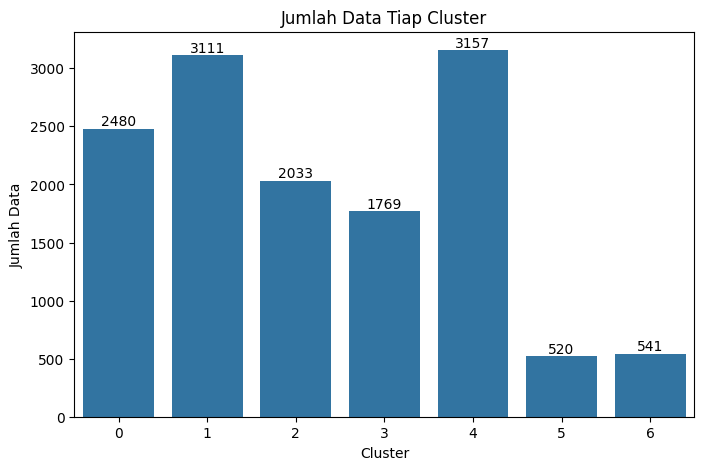


--- Analisis Dominasi Kelas ---
Cluster 0 -> Dominan Class: CALI | Persentase: 52.54%
Cluster 1 -> Dominan Class: SIRA | Persentase: 74.77%
Cluster 2 -> Dominan Class: SEKER | Persentase: 92.18%
Cluster 3 -> Dominan Class: HOROZ | Persentase: 93.89%
Cluster 4 -> Dominan Class: DERMASON | Persentase: 92.24%
Cluster 5 -> Dominan Class: BOMBAY | Persentase: 100.00%
Cluster 6 -> Dominan Class: CALI | Persentase: 49.91%

Tabel Dominasi Cluster:


,Cluster,Dominan_Class,Persentase_Dominasi
0,0,CALI,52.540323
1,1,SIRA,74.766956
2,2,SEKER,92.179046
3,3,HOROZ,93.894856
4,4,DERMASON,92.239468
5,5,BOMBAY,100.000000
6,6,CALI,49.907579


In [13]:
## 6. Analisis Distribusi dan Dominasi Kelas Per Kluster
# VISUALISASI JUMLAH DATA TIAP CLUSTER
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Cluster', data=df)
plt.title('Jumlah Data Tiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()

# ANALISIS DOMINASI
print("\n--- Analisis Dominasi Kelas ---")
dominance_list = []
dominant_classes = []

for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    dominant_class = subset['Class'].mode()[0]
    percentage = subset['Class'].value_counts(normalize=True).max() * 100

    dominance_list.append(percentage)
    dominant_classes.append(dominant_class)

    print(f"Cluster {cluster} -> Dominan Class: {dominant_class} | Persentase: {percentage:.2f}%")

# TABEL DOMINASI
hasil_cluster = pd.DataFrame({
    'Cluster': range(len(dominance_list)),
    'Dominan_Class': dominant_classes,
    'Persentase_Dominasi': dominance_list
})
print("\nTabel Dominasi Cluster:")
display(hasil_cluster)

In [14]:
## 7. Centroid Kluster & Ekspor Data Hasil Kluster
# MENAMPILKAN TITIK TENGAH (CENTROID) TIAP CLUSTER
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
print("Centroid Cluster:")
display(centroids)

# MENYIMPAN HASIL CLUSTERING
df.to_csv('dry_bean_clustered.csv', index=False)
print("\nFile berhasil disimpan: dry_bean_clustered.csv")

Centroid Cluster:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,0.715212,0.957795,0.864472,0.840709,0.254718,0.401069,0.717723,0.901150,0.150800,-0.445556,-0.805539,-0.336278,-1.065574,-0.821873,-0.357631,-0.302507
1,-0.293724,-0.285607,-0.255670,-0.271694,-0.046997,0.190449,-0.295400,-0.263488,-0.042661,0.189593,0.169947,-0.048173,0.170162,-0.055383,-0.081382,0.150618
2,-0.465547,-0.622371,-0.834033,-0.020438,-1.408616,-1.864627,-0.469808,-0.499597,0.475298,0.691385,1.237248,1.618370,-0.180801,1.447196,1.681921,0.748539
3,0.021440,0.301547,0.624801,-0.420046,1.852847,1.294660,0.020610,0.131054,-0.952881,-0.038916,-1.322851,-1.638300,0.408135,-1.141105,-1.564676,-0.339041
4,-0.733458,-0.920106,-0.897248,-0.831097,-0.426981,-0.197591,-0.734125,-0.898229,0.129809,0.254626,0.634052,0.363395,1.088009,0.811287,0.334128,0.453167
5,4.113468,3.412174,3.190343,3.830607,0.010596,0.214515,4.105078,3.652591,0.547970,-0.042899,-0.147609,-0.118424,-2.769075,-1.464180,-0.146497,-0.730361
6,0.416087,0.694042,0.767924,0.326712,0.818863,0.786766,0.444900,0.563895,-0.400468,-2.963279,-1.166573,-0.912783,-0.436411,-0.947971,-0.905712,-3.126126



File berhasil disimpan: dry_bean_clustered.csv


# C. SUPERVISED LEARNING


In [15]:
# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

In [16]:
## 2. Splitting Data Train & Test (train = 80, test = 20)
# MEMBACA DATASET
df = pd.read_csv('dry_bean_preprocessed.csv')

le = LabelEncoder()
df['Class_Label'] = le.fit_transform(df['Class'])

X = df.drop(['Class', 'Class_Label'], axis=1)
y = df['Class_Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah Data Training : {X_train.shape[0]}")
print(f"Jumlah Data Testing  : {X_test.shape[0]}")

Jumlah Data Training : 10888
Jumlah Data Testing  : 2723


Accuracy Naive Bayes: 0.8979

Classification Report Naive Bayes:
              precision    recall  f1-score   support

    BARBUNYA       0.90      0.80      0.85       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.86      0.92      0.89       326
    DERMASON       0.93      0.86      0.90       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.92      0.94      0.93       406
        SIRA       0.81      0.89      0.84       527

    accuracy                           0.90      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



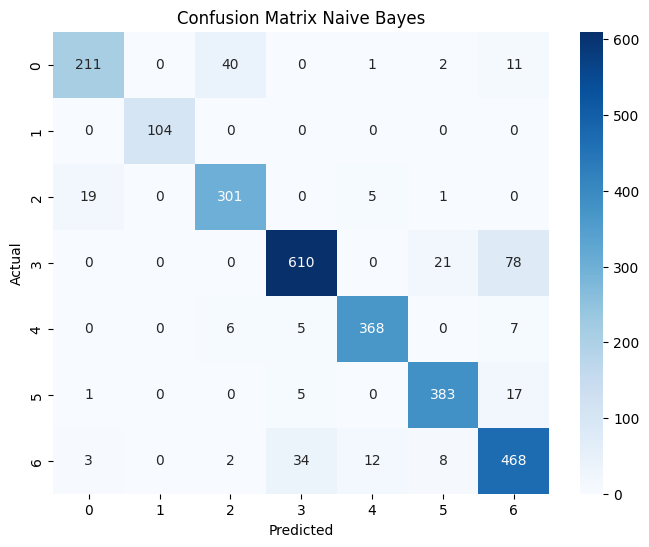

In [17]:
## 3. Klasifikasi Menggunakan Gaussian Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# MENGHITUNG METRIK UTAMA
acc_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy Naive Bayes: {acc_nb:.4f}\n")
print("Classification Report Naive Bayes:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

# CONFUSION MATRIX
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy ANN: 0.9254

Classification Report ANN:
              precision    recall  f1-score   support

    BARBUNYA       0.91      0.93      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.97      0.92      0.95       326
    DERMASON       0.92      0.92      0.92       709
       HOROZ       0.95      0.96      0.95       386
       SEKER       0.95      0.95      0.95       406
        SIRA       0.87      0.87      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



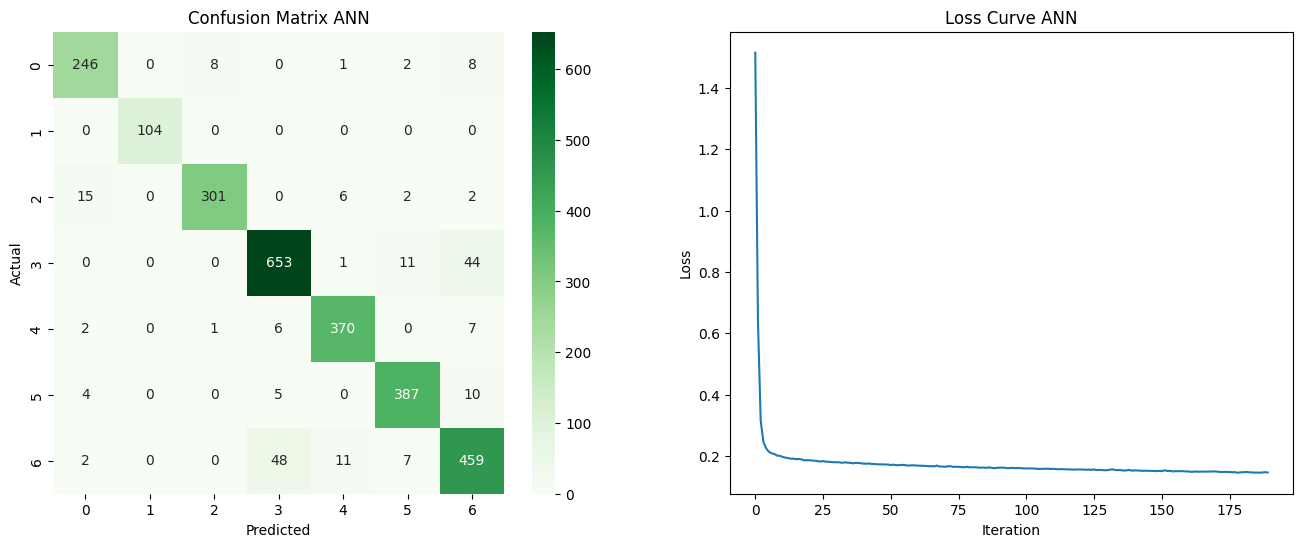

In [18]:
## 4. Klasifikasi Menggunakan ANN (MLP Classifier)
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

# MENGHITUNG METRIK UTAMA
acc_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp, average='weighted')
recall_mlp = recall_score(y_test, y_pred_mlp, average='weighted')
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')

print(f"Accuracy ANN: {acc_mlp:.4f}\n")
print("Classification Report ANN:")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

# CONFUSION MATRIX & LOSS CURVE
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Confusion Matrix ANN')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

ax[1].plot(mlp.loss_curve_)
ax[1].set_title('Loss Curve ANN')
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('Loss')

plt.show()

In [19]:
## 5. Komparasi Performa Global Model
hasil = pd.DataFrame({
    'Model': ['Naive Bayes', 'ANN'],
    'Accuracy': [acc_nb, acc_mlp],
    'Precision': [precision_nb, precision_mlp],
    'Recall': [recall_nb, recall_mlp],
    'F1-Score': [f1_nb, f1_mlp]
})
print("Tabel Perbandingan Model Utama:")
display(hasil)

Tabel Perbandingan Model Utama:


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.897907,0.900702,0.897907,0.898075
1,ANN,0.925450,0.925757,0.925450,0.925520


Tabel Performa Tiap Kelas:


,Class,Recall Naive Bayes,Recall ANN,F1-Score Naive Bayes,F1-Score ANN
0,BARBUNYA,0.796226,0.928302,0.845691,0.921348
1,BOMBAY,1.000000,1.000000,1.000000,1.000000
2,CALI,0.923313,0.923313,0.891852,0.946541
3,DERMASON,0.860367,0.921016,0.895084,0.919071
4,HOROZ,0.953368,0.958549,0.953368,0.954839
5,SEKER,0.943350,0.953202,0.933009,0.949693
6,SIRA,0.888046,0.870968,0.844765,0.868496


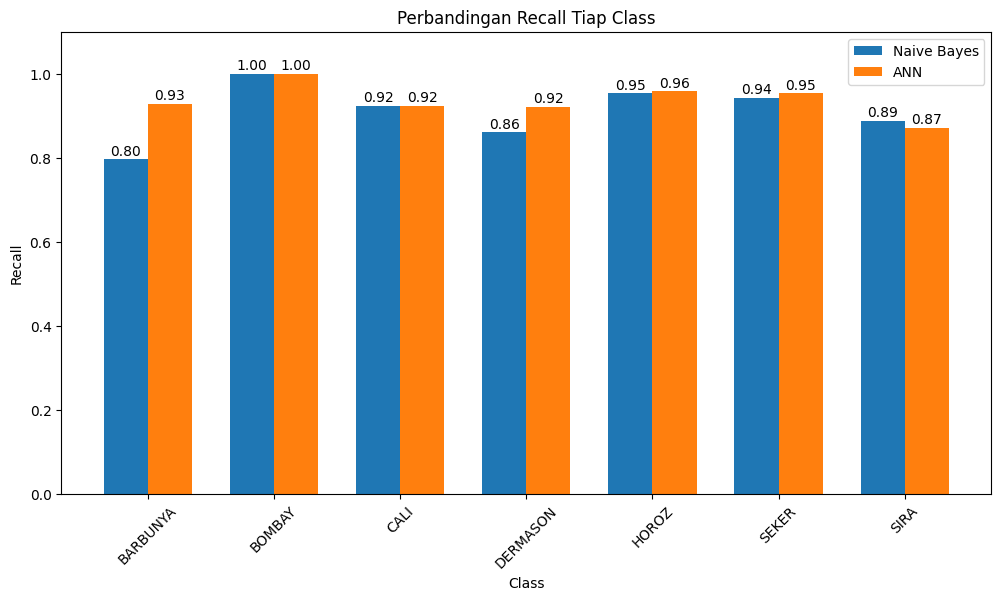

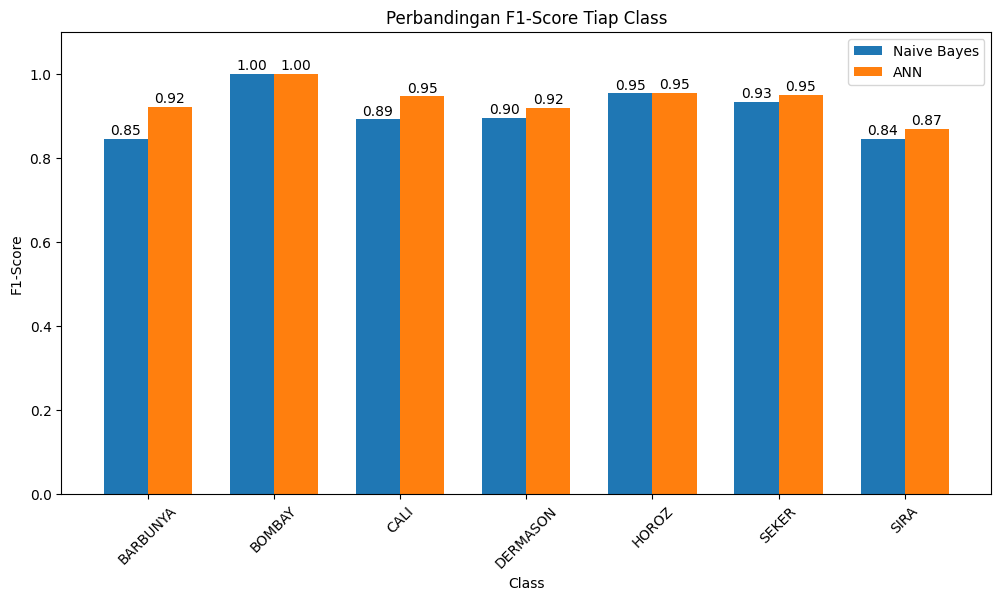

In [20]:
## 6. Komparasi Performa Berdasarkan Tiap Kelas (Recall & F1-Score)
per_class_comparison = pd.DataFrame({
    'Class': le.classes_,
    'Recall Naive Bayes': recall_score(y_test, y_pred_nb, average=None),
    'Recall ANN': recall_score(y_test, y_pred_mlp, average=None),
    'F1-Score Naive Bayes': f1_score(y_test, y_pred_nb, average=None),
    'F1-Score ANN': f1_score(y_test, y_pred_mlp, average=None)
})

print("Tabel Performa Tiap Kelas:")
display(per_class_comparison)

# VISUALISASI RECALL PER CLASS
x = np.arange(len(le.classes_))
width = 0.35
plt.figure(figsize=(12,6))
plt.bar(x - width/2, per_class_comparison['Recall Naive Bayes'], width, label='Naive Bayes')
plt.bar(x + width/2, per_class_comparison['Recall ANN'], width, label='ANN')
plt.xticks(x, le.classes_, rotation=45)
plt.title('Perbandingan Recall Tiap Class')
plt.xlabel('Class')
plt.ylabel('Recall')
plt.legend()

for i, v in enumerate(per_class_comparison['Recall Naive Bayes']):
    plt.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center')
for i, v in enumerate(per_class_comparison['Recall ANN']):
    plt.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center')
plt.ylim(0, 1.1)
plt.show()

# VISUALISASI F1-SCORE PER CLASS
plt.figure(figsize=(12,6))
plt.bar(x - width/2, per_class_comparison['F1-Score Naive Bayes'], width, label='Naive Bayes')
plt.bar(x + width/2, per_class_comparison['F1-Score ANN'], width, label='ANN')
plt.xticks(x, le.classes_, rotation=45)
plt.title('Perbandingan F1-Score Tiap Class')
plt.xlabel('Class')
plt.ylabel('F1-Score')
plt.legend()

for i, v in enumerate(per_class_comparison['F1-Score Naive Bayes']):
    plt.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center')
for i, v in enumerate(per_class_comparison['F1-Score ANN']):
    plt.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center')
plt.ylim(0, 1.1)
plt.show()

# D. INTEGRATION ANALYSIS


In [21]:
# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Crosstab Cluster vs Class:


Class,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
Cluster,,,,,,,
0,1142,1,1303,0,29,0,5
1,114,0,25,499,49,98,2326
2,18,0,2,115,0,1874,24
3,8,0,30,7,1661,0,63
4,0,0,0,2912,2,52,191
5,0,520,0,0,0,0,0
6,40,1,270,13,187,3,27


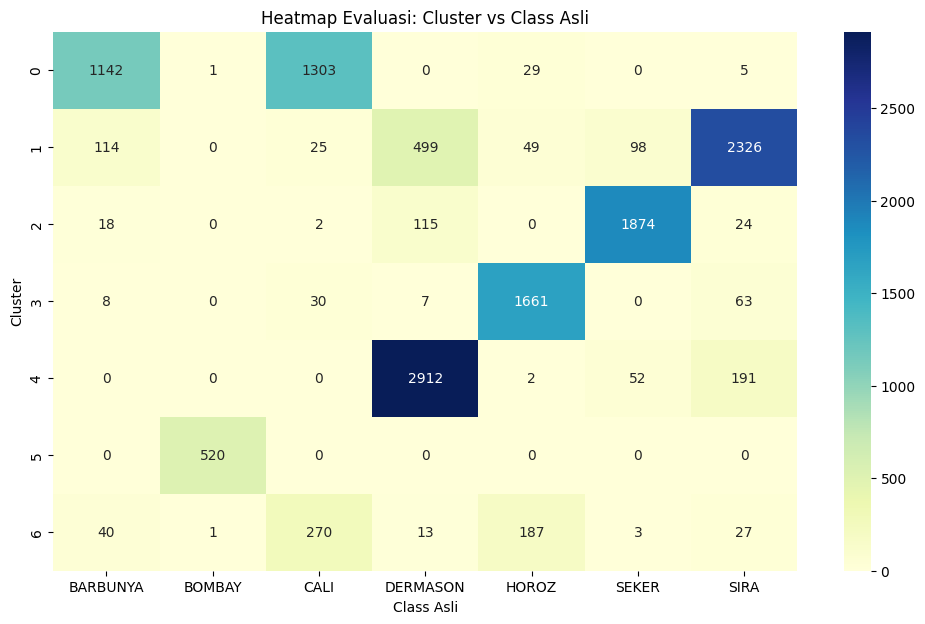

In [22]:
## 2. Memuat Hasil Kluster & Evaluasi Crosstab
# MEMBACA DATASET HASIL CLUSTERING
df = pd.read_csv('dry_bean_clustered.csv')

# MEMBUAT CROSSTAB
cross = pd.create_table = pd.crosstab(df['Cluster'], df['Class'])
print("Crosstab Cluster vs Class:")
display(cross)

# VISUALISASI HEATMAP CROSSTAB
plt.figure(figsize=(12,7))
sns.heatmap(cross, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap Evaluasi: Cluster vs Class Asli')
plt.xlabel('Class Asli')
plt.ylabel('Cluster')
plt.show()

In [23]:
## 3. Perhitungan Metrik Dominasi Kelas Per Kluster
dominance_list = []
dominant_classes = []

for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    dominant_class = subset['Class'].mode()[0]
    percentage = subset['Class'].value_counts(normalize=True).max() * 100

    dominance_list.append(percentage)
    dominant_classes.append(dominant_class)

# MEMBUAT TABEL HASIL ANALISIS
hasil_cluster = pd.DataFrame({
    'Cluster': range(len(dominance_list)),
    'Dominan_Class': dominant_classes,
    'Persentase_Dominasi': dominance_list
})

print("Tabel Dominasi Hasil Integrasi:")
display(hasil_cluster)

Tabel Dominasi Hasil Integrasi:


,Cluster,Dominan_Class,Persentase_Dominasi
0,0,CALI,52.540323
1,1,SIRA,74.766956
2,2,SEKER,92.179046
3,3,HOROZ,93.894856
4,4,DERMASON,92.239468
5,5,BOMBAY,100.000000
6,6,CALI,49.907579


In [24]:
## 4. Kesimpulan Statistik Hasil Integrasi
best_cluster = np.argmax(dominance_list)
worst_cluster = np.argmin(dominance_list)
best_score = dominance_list[best_cluster]
worst_score = dominance_list[worst_cluster]
average_score = np.mean(dominance_list)

high_clusters = sum(1 for score in dominance_list if score >= 80)
low_clusters = len(dominance_list) - high_clusters

print("KESIMPULAN ANALISIS INTEGRASI")
print(f"Total Cluster                : {len(dominance_list)}")
print(f"Cluster Dominasi Tinggi (>=80%): {high_clusters}")
print(f"Cluster Dominasi Rendah (<80%) : {low_clusters}")
print(f"Rata-rata Dominasi Cluster   : {average_score:.2f}%\n")
print(f"Cluster Terbaik              : Cluster {best_cluster} ({dominant_classes[best_cluster]} - {best_score:.2f}%)")
print(f"Cluster Terendah             : Cluster {worst_cluster} ({dominant_classes[worst_cluster]} - {worst_score:.2f}%)")

KESIMPULAN ANALISIS INTEGRASI
Total Cluster                : 7
Cluster Dominasi Tinggi (>=80%): 4
Cluster Dominasi Rendah (<80%) : 3
Rata-rata Dominasi Cluster   : 79.36%

Cluster Terbaik              : Cluster 5 (BOMBAY - 100.00%)
Cluster Terendah             : Cluster 6 (CALI - 49.91%)


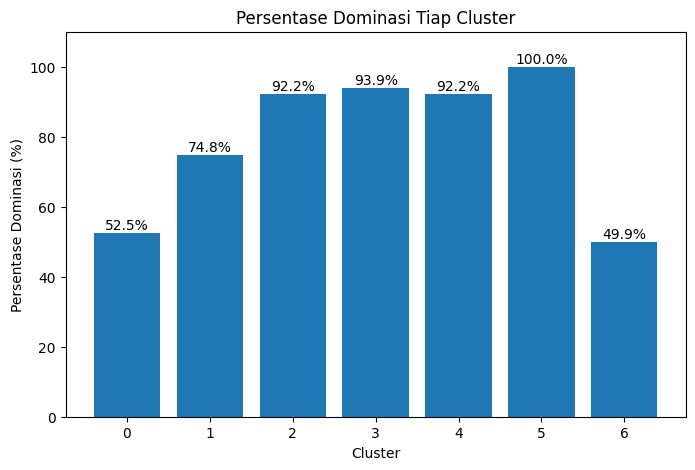

In [25]:
## 5. Visualisasi Perbandingan Persentase Dominasi
plt.figure(figsize=(8,5))
bars = plt.bar(range(len(dominance_list)), dominance_list)

plt.title('Persentase Dominasi Tiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Persentase Dominasi (%)')

for i, v in enumerate(dominance_list):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.ylim(0, 110)
plt.show()